In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [1]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
)


In [6]:
df = pd.read_csv("customer_churn.csv")
print(df.head())

  customer_id  gender  senior_citizen partner dependents  tenure_months  \
0    CUST0001    Male               0      No         No           18.0   
1    CUST0002  Female               0      No         No           32.0   
2    CUST0003    Male               0     Yes        Yes           23.0   
3    CUST0004    Male               0     Yes         No           11.0   
4    CUST0005    Male               0     Yes         No           28.0   

  internet_service        contract    payment_method paperless_billing  \
0              DSL  Month-to-month       Credit card               Yes   
1      Fiber optic  Month-to-month  Electronic check               Yes   
2      Fiber optic        Two year      Mailed check               Yes   
3      Fiber optic  Month-to-month       Credit card               Yes   
4              DSL        Two year  Electronic check               Yes   

   monthly_charges  total_charges churn  
0            37.50         661.14    No  
1            55.44  

In [11]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData types and non-null counts:")
print(df.info())

Shape: (1200, 13)

First 5 rows:
  customer_id  gender  senior_citizen partner dependents  tenure_months  \
0    CUST0001    Male               0      No         No           18.0   
1    CUST0002  Female               0      No         No           32.0   
2    CUST0003    Male               0     Yes        Yes           23.0   
3    CUST0004    Male               0     Yes         No           11.0   
4    CUST0005    Male               0     Yes         No           28.0   

  internet_service        contract    payment_method paperless_billing  \
0              DSL  Month-to-month       Credit card               Yes   
1      Fiber optic  Month-to-month  Electronic check               Yes   
2      Fiber optic        Two year      Mailed check               Yes   
3      Fiber optic  Month-to-month       Credit card               Yes   
4              DSL        Two year  Electronic check               Yes   

   monthly_charges  total_charges churn  
0            37.50         66

In [15]:
print("\nTarget distribution (Churn):")
print(df["churn"].value_counts())


Target distribution (Churn):
churn
No     1020
Yes     180
Name: count, dtype: int64


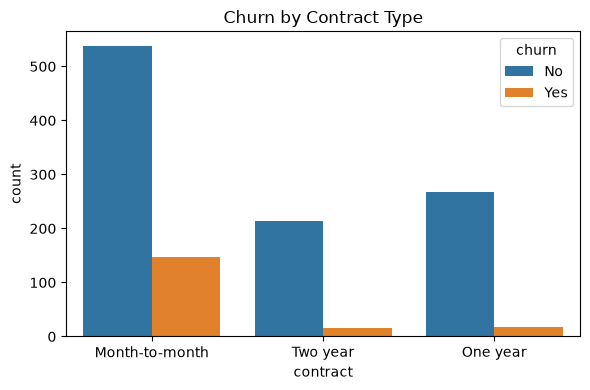

In [18]:
#quick visualization of churn by contract type
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="contract", hue="churn")
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.show()

In [ ]:
# Drop customerID (not useful for modeling)
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])

In [ ]:
# Convert TotalCharges to numeric (it sometimes comes as object with blanks)
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

In [ ]:
# Fill missing TotalCharges with median (simple approach)
df["total_charges"] = df["total_charges"].fillna(df["total_charges"].median())

In [20]:
# Target variable: Churn Yes -> 1, No -> 0
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})

# Separate features and target
X = df.drop(columns=["churn"])
y = df["churn"]


In [21]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['senior_citizen', 'tenure_months', 'monthly_charges', 'total_charges']
Categorical features: ['customer_id', 'gender', 'partner', 'dependents', 'internet_service', 'contract', 'payment_method', 'paperless_billing']


C:\Users\dell\AppData\Local\Temp\ipykernel_3228\3478097638.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Construct preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
# 5. Define models inside pipelines

# Logistic Regression
log_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])


In [25]:
# Decision Tree
dt_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        random_state=42,
        class_weight="balanced"
    ))
])

# Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    ))
])


In [26]:
# 6. Train models
print("\n=== Training Logistic Regression ===")
log_reg_pipe.fit(X_train, y_train)

print("\n=== Training Decision Tree ===")
dt_pipe.fit(X_train, y_train)

print("\n=== Training Random Forest ===")
rf_pipe.fit(X_train, y_train)


=== Training Logistic Regression ===


C:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Training Decision Tree ===

=== Training Random Forest ===


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['customer_id','gender','senior_citizen',...,'paperless_billing', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema


Logistic Regression
Accuracy: 0.7166666666666667
ROC-AUC: 0.6816448801742919

Classification report:
               precision    recall  f1-score   support

           0     0.8778    0.7745    0.8229       204
           1     0.2333    0.3889    0.2917        36

    accuracy                         0.7167       240
   macro avg     0.5556    0.5817    0.5573       240
weighted avg     0.7811    0.7167    0.7432       240



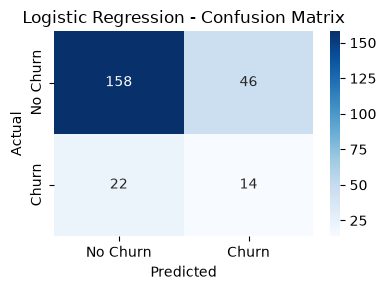


Decision Tree
Accuracy: 0.6208333333333333
ROC-AUC: 0.6467184095860565

Classification report:
               precision    recall  f1-score   support

           0     0.9065    0.6176    0.7347       204
           1     0.2277    0.6389    0.3358        36

    accuracy                         0.6208       240
   macro avg     0.5671    0.6283    0.5352       240
weighted avg     0.8047    0.6208    0.6749       240



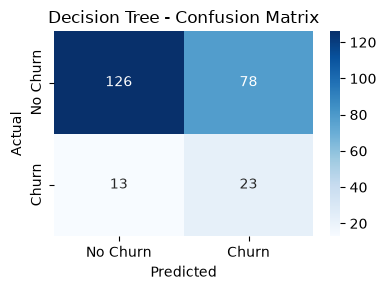


Random Forest
Accuracy: 0.7041666666666667
ROC-AUC: 0.670479302832244

Classification report:
               precision    recall  f1-score   support

           0     0.8982    0.7353    0.8086       204
           1     0.2603    0.5278    0.3486        36

    accuracy                         0.7042       240
   macro avg     0.5792    0.6315    0.5786       240
weighted avg     0.8025    0.7042    0.7396       240



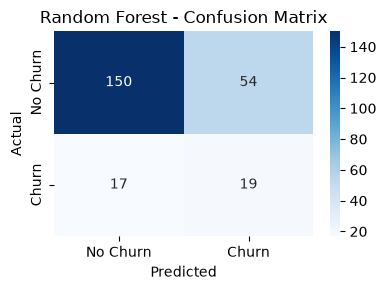

In [27]:
#Evaluate models

def evaluate_model(pipe, name, X_test, y_test):
    y_pred = pipe.predict(X_test)
    # For ROC-AUC we need probabilities for class 1
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

evaluate_model(log_reg_pipe, "Logistic Regression", X_test, y_test)
evaluate_model(dt_pipe, "Decision Tree", X_test, y_test)
evaluate_model(rf_pipe, "Random Forest", X_test, y_test)

In [29]:
# Get feature names after one-hot encoding
ohe = log_reg_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

rf_model = rf_pipe.named_steps["model"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 15 important features (Random Forest):")
print(feat_imp.head(15))


Top 15 important features (Random Forest):
                             feature  importance
1                      tenure_months    0.154253
973          contract_Month-to-month    0.091486
3                      total_charges    0.077995
975                contract_Two year    0.063078
974                contract_One year    0.050294
2                    monthly_charges    0.043206
978  payment_method_Electronic check    0.033158
971     internet_service_Fiber optic    0.021843
0                     senior_citizen    0.015846
979      payment_method_Mailed check    0.014776
972              internet_service_No    0.014496
970             internet_service_DSL    0.012891
977       payment_method_Credit card    0.010660
130             customer_id_CUST0162    0.008133
158             customer_id_CUST0196    0.006613


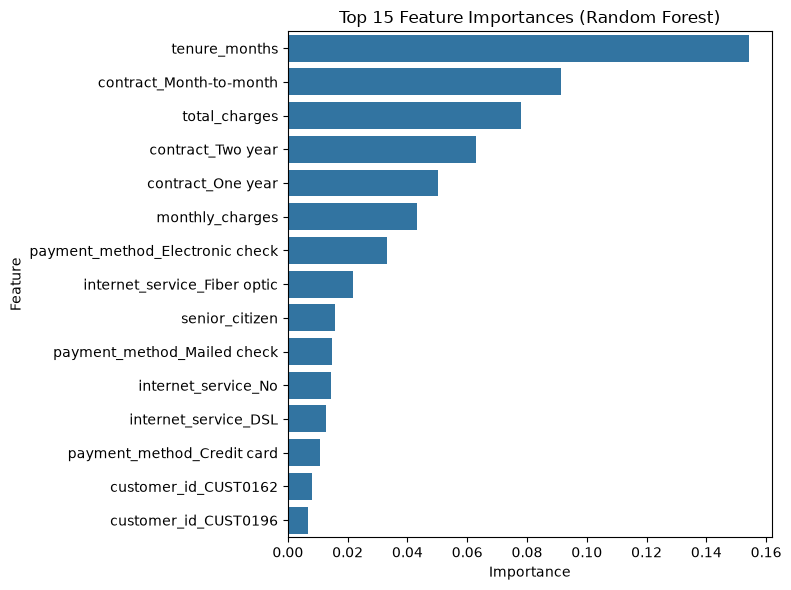

In [30]:
# Plot top 15 feature importances
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
# Get coefficients and feature names from the same preprocessed space
log_reg_model = log_reg_pipe.named_steps["model"]
coefs = log_reg_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefs
}).sort_values(by="coefficient", ascending=False)

print("\nLogistic Regression coefficients (top 10 positive and negative):")
print("Top 10 positive (increase churn odds):")
print(coef_df.head(10))
print("\nTop 10 negative (decrease churn odds):")
print(coef_df.tail(10))


Logistic Regression coefficients (top 10 positive and negative):
Top 10 positive (increase churn odds):
                  feature  coefficient
717  customer_id_CUST0889     2.298884
215  customer_id_CUST0266     1.993553
729  customer_id_CUST0908     1.850546
203  customer_id_CUST0251     1.756769
707  customer_id_CUST0879     1.664949
942  customer_id_CUST1172     1.656367
238  customer_id_CUST0296     1.625927
753  customer_id_CUST0941     1.604579
843  customer_id_CUST1054     1.604248
526  customer_id_CUST0650     1.588660

Top 10 negative (decrease churn odds):
                  feature  coefficient
454  customer_id_CUST0560    -0.376186
974     contract_One year    -0.383396
862  customer_id_CUST1075    -0.388583
340  customer_id_CUST0417    -0.400982
413  customer_id_CUST0508    -0.402944
737  customer_id_CUST0920    -0.404113
302  customer_id_CUST0370    -0.406917
346  customer_id_CUST0423    -0.425415
975     contract_Two year    -0.602728
972   internet_service_No    -0.6110